<a href="https://colab.research.google.com/github/MONJIT07/SN-BOSE-/blob/main/ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
model_df=pd.read_csv('hourlyLoadData_NE_weather_with_holiday.csv')


In [ ]:
print(model_df.head())
#%%


        datetime  North-Eastern Region Hourly Demand  temp_ne  humidity_ne  \
0  1/1/2019 0:00                             1665.72     11.4           91   
1  1/1/2019 1:00                             1556.24     10.4           92   
2  1/1/2019 2:00                             1485.44      9.6           93   
3  1/1/2019 3:00                             1454.96      9.1           91   
4  1/1/2019 4:00                             1463.14      8.9           88   

   feels_like_ne  is_holiday  
0           10.7           1  
1            9.6           1  
2            8.5           1  
3            7.7           1  
4            7.5           1  


In [ ]:
model_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46728 entries, 0 to 46727
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   datetime                            46728 non-null  object 
 1   North-Eastern Region Hourly Demand  46728 non-null  float64
 2   temp_ne                             46728 non-null  float64
 3   humidity_ne                         46728 non-null  int64  
 4   feels_like_ne                       46728 non-null  float64
 5   is_holiday                          46728 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 2.1+ MB


In [ ]:
model_df.describe()


,North-Eastern Region Hourly Demand,temp_ne,humidity_ne,feels_like_ne,is_holiday
count,46728.00000,46728.000000,46728.000000,46728.000000,46728.000000
mean,2007.36047,23.520611,79.603642,26.709123,0.045198
std,436.58010,5.206864,15.549451,7.344566,0.207740
min,567.00000,7.900000,16.000000,6.400000,0.000000
25%,1689.17750,20.000000,70.000000,21.000000,0.000000
50%,1968.65000,24.500000,84.000000,27.800000,0.000000
75%,2290.20250,27.200000,92.000000,32.600000,0.000000
max,3586.43000,38.800000,100.000000,44.800000,1.000000


<Axes: >

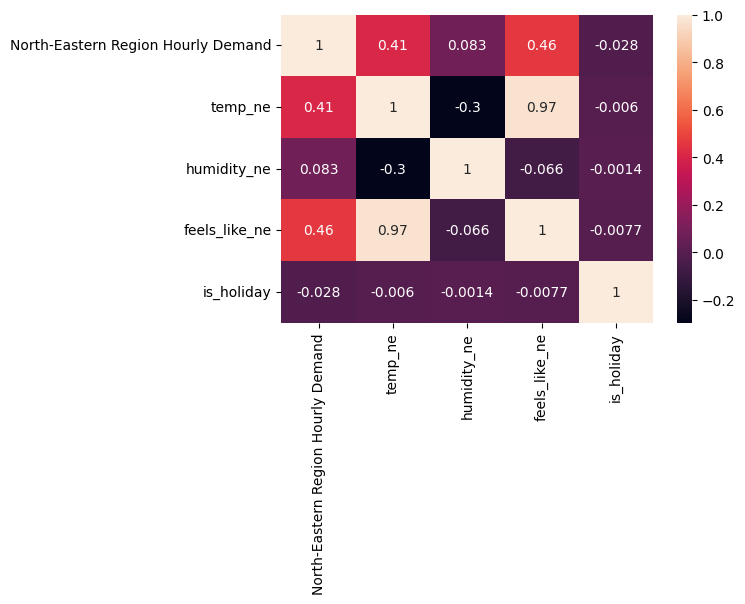

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(model_df.corr(numeric_only=True),annot=True)

In [ ]:
print(model_df.dtypes)
print(model_df['datetime'].head(5))

datetime                               object
North-Eastern Region Hourly Demand    float64
temp_ne                               float64
humidity_ne                             int64
feels_like_ne                         float64
is_holiday                              int64
dtype: object
0    1/1/2019 0:00
1    1/1/2019 1:00
2    1/1/2019 2:00
3    1/1/2019 3:00
4    1/1/2019 4:00
Name: datetime, dtype: object


In [ ]:
model_df['datetime']=pd.to_datetime(model_df['datetime'])
print(model_df['datetime'].dtype)
print(model_df['datetime'].head(3))

datetime64[ns]
0   2019-01-01 00:00:00
1   2019-01-01 01:00:00
2   2019-01-01 02:00:00
Name: datetime, dtype: datetime64[ns]


In [ ]:
model_df['hour']=model_df['datetime'].dt.hour
model_df['day_of_week']=model_df['datetime'].dt.dayofweek
model_df['day_of_month']=model_df['datetime'].dt.day
model_df['month']=model_df['datetime'].dt.month
model_df['quarter']=model_df['datetime'].dt.quarter
model_df['year']=model_df['datetime'].dt.year
model_df['is_weekend']=(model_df['datetime'].dt.dayofweek >= 5).astype(int)
print(model_df[['datetime','hour','day_of_week','month','year','is_weekend']].head(5))

             datetime  hour  day_of_week  month  year  is_weekend
0 2019-01-01 00:00:00     0            1      1  2019           0
1 2019-01-01 01:00:00     1            1      1  2019           0
2 2019-01-01 02:00:00     2            1      1  2019           0
3 2019-01-01 03:00:00     3            1      1  2019           0
4 2019-01-01 04:00:00     4            1      1  2019           0


In [ ]:
model_df['hour_sin']=np.sin(2*np.pi*model_df['hour']/24)
model_df['hour_cos']=np.cos(2*np.pi*model_df['hour']/24)

model_df['dow_sin']=np.sin(2*np.pi*model_df['day_of_week']/7)
model_df['dow_cos']=np.cos(2*np.pi*model_df['day_of_week']/7)

model_df['month_sin']=np.sin(2*np.pi*model_df['month']/12)
model_df['month_cos']=np.cos(2*np.pi*model_df['month']/12)

print(model_df[['hour','hour_sin','hour_cos','day_of_week','dow_sin','dow_cos']].head(5))

   hour  hour_sin  hour_cos  day_of_week   dow_sin  dow_cos
0     0  0.000000  1.000000            1  0.781831  0.62349
1     1  0.258819  0.965926            1  0.781831  0.62349
2     2  0.500000  0.866025            1  0.781831  0.62349
3     3  0.707107  0.707107            1  0.781831  0.62349
4     4  0.866025  0.500000            1  0.781831  0.62349


In [ ]:
TARGET='North-Eastern Region Hourly Demand'
model_df['lag_1h']=model_df[TARGET].shift(1)
model_df['lag_24h']=model_df[TARGET].shift(24)
model_df['lag_48h']=model_df[TARGET].shift(48)
model_df['lag_168h']=model_df[TARGET].shift(168)
model_df['lag_336h']=model_df[TARGET].shift(336)
model_df['rolling_mean_24h']=model_df[TARGET].shift(1).rolling(24).mean()
model_df['rolling_mean_168h']=model_df[TARGET].shift(1).rolling(168).mean()
model_df['rolling_std_24h']=model_df[TARGET].shift(1).rolling(24).std()
model_df['rolling_max_24h']=model_df[TARGET].shift(1).rolling(24).max()
model_df['rolling_min_24h']=model_df[TARGET].shift(1).rolling(24).min()

model_df.head(5)

,datetime,North-Eastern Region Hourly Demand,temp_ne,humidity_ne,feels_like_ne,is_holiday,hour,day_of_week,day_of_month,month,...,lag_1h,lag_24h,lag_48h,lag_168h,lag_336h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_max_24h,rolling_min_24h
0,2019-01-01 00:00:00,1665.72,11.4,91,10.7,1,0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-01 01:00:00,1556.24,10.4,92,9.6,1,1,1,1,1,...,1665.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-01 02:00:00,1485.44,9.6,93,8.5,1,2,1,1,1,...,1556.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-01 03:00:00,1454.96,9.1,91,7.7,1,3,1,1,1,...,1485.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-01 04:00:00,1463.14,8.9,88,7.5,1,4,1,1,1,...,1454.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(model_df.shape)
model_df.dropna(inplace=True)
model_df.reset_index(drop=True, inplace=True)
print(model_df.shape)

(46728, 29)
(46392, 29)


In [ ]:
feature_cols=[col for col in model_df.columns
                if col not in ['datetime', TARGET]]

print(f"Total features:{len(feature_cols)}")
print("\nFeature list:")
for i,col in enumerate(feature_cols, 1):
    print(f"{i:2d}.{col}")

Total features:27

Feature list:
 1.temp_ne
 2.humidity_ne
 3.feels_like_ne
 4.is_holiday
 5.hour
 6.day_of_week
 7.day_of_month
 8.month
 9.quarter
10.year
11.is_weekend
12.hour_sin
13.hour_cos
14.dow_sin
15.dow_cos
16.month_sin
17.month_cos
18.lag_1h
19.lag_24h
20.lag_48h
21.lag_168h
22.lag_336h
23.rolling_mean_24h
24.rolling_mean_168h
25.rolling_std_24h
26.rolling_max_24h
27.rolling_min_24h


In [ ]:
print(model_df.head())
#%%


             datetime  North-Eastern Region Hourly Demand  temp_ne  \
0 2019-01-15 00:00:00                             1502.11     14.0   
1 2019-01-15 01:00:00                             1404.18     13.7   
2 2019-01-15 02:00:00                             1366.26     13.2   
3 2019-01-15 03:00:00                             1353.51     13.0   
4 2019-01-15 04:00:00                             1363.48     12.8   

   humidity_ne  feels_like_ne  is_holiday  hour  day_of_week  day_of_month  \
0           81           13.1           1     0            1            15   
1           79           12.8           1     1            1            15   
2           78           12.2           1     2            1            15   
3           78           11.6           1     3            1            15   
4           77           11.4           1     4            1            15   

   month  ...   lag_1h  lag_24h  lag_48h  lag_168h  lag_336h  \
0      1  ...  1666.11  1425.06  1471.21   148

In [ ]:
model_df.isnull().sum()


,0
datetime,0
North-Eastern Region Hourly Demand,0
temp_ne,0
humidity_ne,0
feels_like_ne,0
is_holiday,0
hour,0
day_of_week,0
day_of_month,0
month,0


In [ ]:
EXCLUDE=['datetime','North-Eastern Region Hourly Demand']
FEATURE_COLS=[col for col in model_df.columns if col not in EXCLUDE]
TARGET='North-Eastern Region Hourly Demand'

In [ ]:
SPLIT_DATE='2023-01-01'
train=model_df[model_df['datetime']<SPLIT_DATE].copy()
test=model_df[model_df['datetime']>=SPLIT_DATE].copy()
X_train=train[FEATURE_COLS]
y_train=train[TARGET]
X_test=test[FEATURE_COLS]
y_test=test[TARGET]
print(f"X_train shape:{X_train.shape}")
print(f"X_test shape:{X_test.shape}")

X_train shape:(34728, 27)
X_test shape:(11664, 27)


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 24.5 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import numpy as np

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        scores.append(mean_absolute_error(y_val, model.predict(X_val)))
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-07-03 06:55:32,114] A new study created in memory with name: no-name-164da69b-88ed-495d-9754-e8e85b30080c


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-03 06:56:43,759] Trial 0 finished with value: 40.50729950361443 and parameters: {'n_estimators': 1400, 'learning_rate': 0.008019714419442731, 'max_depth': 8, 'num_leaves': 197, 'min_child_samples': 8, 'subsample': 0.9417282259029046, 'colsample_bytree': 0.7487955363536378, 'reg_alpha': 0.07480015596744193, 'reg_lambda': 0.7956145532444238}. Best is trial 0 with value: 40.50729950361443.
[I 2026-07-03 06:57:17,898] Trial 1 finished with value: 43.91808970864501 and parameters: {'n_estimators': 1000, 'learning_rate': 0.0053735230249293085, 'max_depth': 9, 'num_leaves': 28, 'min_child_samples': 51, 'subsample': 0.6519404682444976, 'colsample_bytree': 0.9770653001545409, 'reg_alpha': 0.003857252908335362, 'reg_lambda': 0.005238448223335745}. Best is trial 0 with value: 40.50729950361443.
[I 2026-07-03 06:57:22,742] Trial 2 finished with value: 43.563230554655604 and parameters: {'n_estimators': 1000, 'learning_rate': 0.19556692778481358, 'max_depth': 12, 'num_leaves': 141, 'min_

In [ ]:
print("Best MAE (CV):", study.best_value)
print("Best params:", study.best_params)

In [ ]:
best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True), lgb.log_evaluation(period=100)]
)

print(f"  Best iteration : {final_model.best_iteration_}")

In [ ]:
y_pred = final_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_pred.mean())**2)

print(f"  MAE   : {mae:>10,.2f} MW")
print(f"  RMSE  : {rmse:>10,.2f} MW")
print(f"  MAPE  : {mape:>10.2f} %")
print(f"  R²    : {r2:>10.4f}")

In [ ]:
import matplotlib.pyplot as plt

plot_df = test.iloc[:168].copy()
plot_pred = y_pred[:168]

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(test['datetime'], y_test.values,
             color='#4e79a7', linewidth=0.8, label='Actual', alpha=0.9)
axes[0].plot(test['datetime'], y_pred,
             color='#e15759', linewidth=0.8, label='Predicted', alpha=0.8)
axes[0].set_title('LightGBM (Tuned) — Actual vs Predicted (Full Test Period)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(plot_df['datetime'], plot_df[TARGET].values,
             color='#4e79a7', linewidth=1.5, label='Actual')
axes[1].plot(plot_df['datetime'], plot_pred,
             color='#e15759', linewidth=1.5, label='Predicted', linestyle='--')
axes[1].set_title('First 7 Days of Test Set', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('lgbm_predictions_tuned.png', dpi=150)
plt.show()

In [ ]:
print(f"Original (hand-picked) MAE: <fill i")
print(f"Tuned (Optuna) MAE       : {mae:,.2f} MW")